In [17]:
import pandas as pd
import matplotlib.pyplot as plt

<Axes: title={'center': 'Iran cinema production trend'}, xlabel='startYear'>

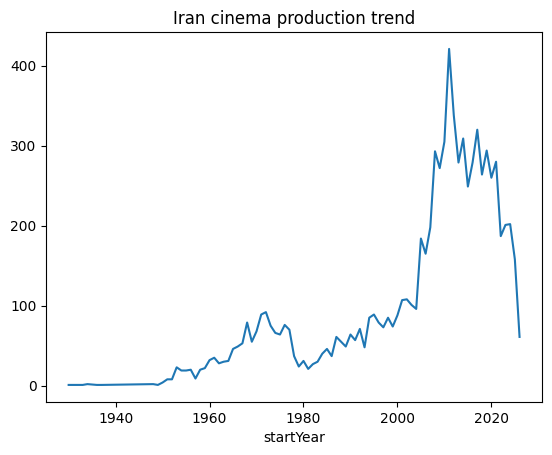

In [18]:
df = pd.read_parquet('../data/processed/iran_cinema_clean.parquet')

df_films_per_year = df.drop_duplicates('tconst').groupby('startYear').size()
df_films_per_year.plot(kind='line', title='Iran cinema production trend')

In [19]:
top_people = df.groupby(['nconst', 'primaryName']).size().sort_values(ascending=False).head(20)
print(top_people)

nconst     primaryName          
nm0451571  Hamideh Kheirabadi       168
nm2465620  Mehdi Aminikhah          148
nm1714957  Kianoosh Gerami          136
nm1028434  Reza Beyk Imanverdi      129
nm2932763  Siamak Ash'arioon        128
nm1286513  Kazem Afrandnia          126
nm5747379  Heshmatollah Aramideh    123
nm0556305  Jamshid Mashayekhi       116
nm0707308  Mehran Rajabi            115
nm0539339  Naser Malek Motiee       111
nm0994308  Iraj Ghaderi             110
nm2114785  Behnoosh Bakhtiari       109
nm5250420  Hasan Asadi              109
nm0049076  Enayat Bakhshi           109
nm0008206  Akbar Abdi               109
nm1184348  Dariush Asadzade         109
nm1824944  Ali Miri                 106
nm1164771  Ahmad Ghadakchian        105
nm2182713  Saideh Arab              105
nm2746789  Mir Taher Mazloomi       102
dtype: int64


<Axes: title={'center': 'repetetive genres'}, xlabel='genres'>

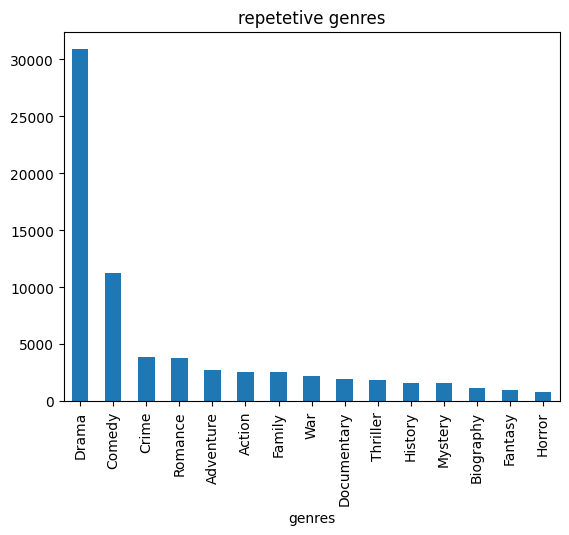

In [20]:
genre_counts = df['genres'].dropna().str.split(',').explode().value_counts()
genre_counts.head(15).plot(kind='bar', title='repetetive genres')

In [21]:
df_ratings = pd.read_csv('../data/raw/title.ratings.tsv.gz', sep='\t')

In [22]:
df_films_rated = df.merge(df_ratings, on='tconst', how='left')

درصد فیلم هایی که براشون امتیاز ثبت شده

In [23]:
print(df_films_rated['averageRating'].notna().mean())

0.5809184128399465


فیلم هایی که تعداد رای کمی دارند قابل اعتماد نیستند. باید  threshold برای تعداد رای های مشخض کنیم

In [24]:
print(df_films_rated['numVotes'].describe())

count    42999.000000
mean       160.783855
std        493.002834
min          5.000000
25%         16.000000
50%         32.000000
75%        108.000000
max       7746.000000
Name: numVotes, dtype: float64


In [25]:
df_reliable = df_films_rated[df_films_rated['numVotes'] >= 50]

In [26]:
print(df_films_rated.shape)

(74019, 15)


تست فرضیه: آیا رشد تعداد تولید بعداز سال 200 باعث افت/رشد کیفیت فیلم ها شده یا نه اصلا ربطی نداره ؟

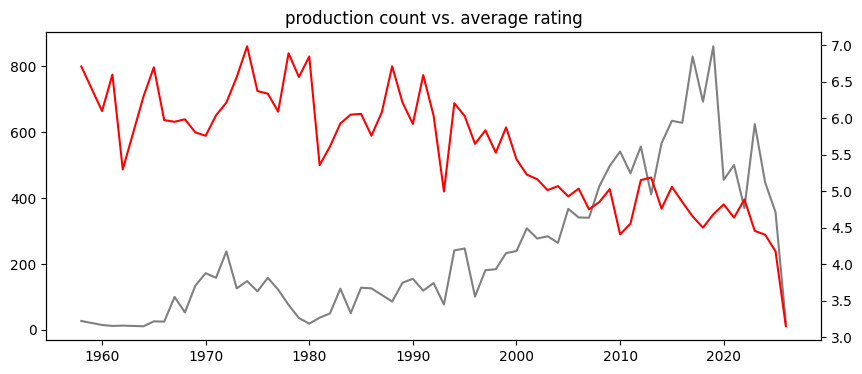

In [31]:
yearly_stats = df_reliable.groupby('startYear').agg(
    film_count=('tconst', 'count'),
    avg_rating=('averageRating', 'mean')
)

fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(yearly_stats.index, yearly_stats['film_count'], color='gray')
ax2 = ax1.twinx()
ax2.plot(yearly_stats.index, yearly_stats['avg_rating'], color='red')
plt.title('production count vs. average rating')
plt.show()